In [1]:
# =============================================================================
#                    ROBUST REGRESSION ENGINE
#                    PART A: CONCEPTUAL FOUNDATION
# =============================================================================
#
# Project Objective:
# The objective of this project is to develop and evaluate supervised
# regression models for predicting house prices. The project focuses on
# regularization, cross-validation, tree-based regression, Support Vector
# Regression, and model evaluation to achieve reliable generalization on
# unseen data.
#
# -----------------------------------------------------------------------------
# Q1. What is Regularization in Machine Learning? Why is it needed?
# -----------------------------------------------------------------------------
# Regularization is a technique used to reduce overfitting by adding a
# penalty to the model's complexity. It discourages excessively large
# coefficients and helps the model learn general patterns instead of
# memorizing the training data. It improves model stability and
# generalization on unseen data.
#
#
# -----------------------------------------------------------------------------
# Q2. Difference between Ridge Regression (L2) and Lasso Regression (L1)
# -----------------------------------------------------------------------------
# Ridge Regression uses L2 regularization, which penalizes the squared
# magnitude of model coefficients. It shrinks coefficients toward zero but
# generally does not make them exactly zero.
#
# Lasso Regression uses L1 regularization, which penalizes the absolute
# magnitude of coefficients. It can reduce some coefficients exactly to zero,
# making Lasso useful for automatic feature selection.
#
#
# -----------------------------------------------------------------------------
# Q3. What is Cross-Validation and why is it important?
# -----------------------------------------------------------------------------
# Cross-validation is a model evaluation technique in which the training
# dataset is divided into multiple subsets (folds). The model is trained and
# validated multiple times using different folds. It provides a more reliable
# estimate of model performance, helps compare models, and helps detect
# overfitting or unstable model behavior.
#
#
# -----------------------------------------------------------------------------
# Q4. Explain the following Cross-Validation techniques
# -----------------------------------------------------------------------------
#
# 1. K-Fold Cross-Validation:
# The dataset is divided into K folds. The model is trained on K-1 folds and
# validated on the remaining fold. This process is repeated K times so that
# every fold is used once for validation.
#
# 2. Stratified K-Fold Cross-Validation:
# Stratified K-Fold maintains a similar distribution of target values across
# the folds. Since house price is a continuous target, the target values are
# first divided into bins and these bins are then used for stratification.
#
# 3. Leave-One-Out Cross-Validation (LOOCV):
# LOOCV uses one observation as the validation set and all remaining
# observations for training. This process is repeated for every observation,
# providing an almost unbiased performance estimate but requiring high
# computational cost.
#
# 4. Time Series Split:
# Time Series Split preserves the chronological order of observations.
# Earlier observations are used for training and later observations are used
# for validation. It is appropriate when the data contains a meaningful
# time-dependent relationship.
#
#
# -----------------------------------------------------------------------------
# Q5. Why are tree-based models less sensitive to feature scaling?
# -----------------------------------------------------------------------------
# Tree-based models make decisions using feature-based threshold conditions
# rather than distance or coefficient magnitude. Therefore, changing the
# numerical scale of a feature generally does not affect the splitting order.
# As a result, Decision Trees and Random Forests usually do not require
# feature scaling.
#
#
# -----------------------------------------------------------------------------
# PART A - KEY LEARNING OUTCOME
# -----------------------------------------------------------------------------
# Regularization controls model complexity and reduces overfitting.
# Cross-validation provides reliable estimates of model generalization.
# Ridge and Lasso handle regularization differently, while tree-based models
# can capture nonlinear relationships without requiring feature scaling.
# These concepts form the theoretical foundation for the regression models
# implemented in the following parts of this project.
#
# =============================================================================
# END OF PART A: CONCEPTUAL FOUNDATION
# =============================================================================


In [2]:
# =============================================================================
# PROJECT LIBRARIES
# =============================================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    GridSearchCV,
    cross_validate,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import (
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.compose import ColumnTransformer

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [3]:
# =============================================================================
# PART B - DATASET UNDERSTANDING & PREPARATION
# =============================================================================


# =============================================================================
# Q6 - IDENTIFY FEATURES AND TARGET
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Load Dataset
# -----------------------------------------------------------------------------

SHEET_ID = "1FYzQsKC_f7zi44C882y-IWLOIK-UuO1f0kK3s-2L-js"
DATA_SOURCE = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"

df = pd.read_csv(DATA_SOURCE)


# ------------------------------ STEP 2 ---------------------------------------
# Inspect Dataset
# -----------------------------------------------------------------------------

display(df.head())
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
display(df.dtypes.to_frame(name="Data Type"))
display(df.describe(include="all").T)


# ------------------------------ STEP 3 ---------------------------------------
# Check Data Quality
# -----------------------------------------------------------------------------

missing = df.isnull().sum()

display(pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df) * 100).round(2)
}))

print("Duplicate Records:", df.duplicated().sum())


# ------------------------------ STEP 4 ---------------------------------------
# Identify Features and Target
# -----------------------------------------------------------------------------

df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")

TARGET = "house_price_inr"
IDENTIFIER = "property_id"

if TARGET not in df.columns or IDENTIFIER not in df.columns:
    raise ValueError("Required column not found.")

X = df.drop(columns=[TARGET, IDENTIFIER, "sale_date"])
y = df[TARGET]

print("Target Variable:", TARGET)
print("Number of Features:", X.shape[1])
print("Number of Records:", X.shape[0])
print("\nFeatures:", X.columns.tolist())


# =============================================================================
# Q7 - TRAIN-TEST SPLIT
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Separate Training and Testing Data
# -----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


# ------------------------------ STEP 2 ---------------------------------------
# Check Training Data
# -----------------------------------------------------------------------------

print("Training Features:", X_train.shape)
print("Training Target:", y_train.shape)


# ------------------------------ STEP 3 ---------------------------------------
# Check Testing Data
# -----------------------------------------------------------------------------

print("Testing Features:", X_test.shape)
print("Testing Target:", y_test.shape)


# ------------------------------ STEP 4 ---------------------------------------
# Verify Train-Test Split
# -----------------------------------------------------------------------------

print(f"Training Data: {len(X_train) / len(X) * 100:.2f}%")
print(f"Testing Data: {len(X_test) / len(X) * 100:.2f}%")

assert len(X_train) + len(X_test) == len(X)
assert len(y_train) + len(y_test) == len(y)


# =============================================================================
# Q8 - BASIC PREPROCESSING AND SCALING
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Identify Numerical and Categorical Features
# -----------------------------------------------------------------------------

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:", numerical_features)
print("\nCategorical Features:", categorical_features)


# ------------------------------ STEP 2 ---------------------------------------
# Create Numerical Preprocessing Pipeline
# -----------------------------------------------------------------------------

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ------------------------------ STEP 3 ---------------------------------------
# Create Categorical Preprocessing Pipeline
# -----------------------------------------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


# ------------------------------ STEP 4 ---------------------------------------
# Combine and Apply Preprocessing
# -----------------------------------------------------------------------------

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original Training Shape:", X_train.shape)
print("Processed Training Shape:", X_train_processed.shape)
print("Original Testing Shape:", X_test.shape)
print("Processed Testing Shape:", X_test_processed.shape)

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


Dataset Shape: (3800, 12)

Column Names: ['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'house_price_inr']


,Data Type
property_id,int64
sale_date,object
area_sqft,int64
bedrooms,int64
bathrooms,int64
location_score,float64
property_age,int64
distance_city_km,float64
near_school,int64
near_metro,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
property_id,3800.0,NaN,NaN,NaN,201900.5,1097.10984,200001.0,200950.75,201900.5,202850.25,203800.0
sale_date,3800,168,2019-05-01,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_sqft,3800.0,NaN,NaN,NaN,1716.925526,582.996559,500.0,1322.0,1700.5,2105.0,3776.0
bedrooms,3800.0,NaN,NaN,NaN,3.428158,1.356682,1.0,2.0,3.0,4.0,7.0
bathrooms,3800.0,NaN,NaN,NaN,2.916316,1.13354,1.0,2.0,3.0,4.0,6.0
location_score,3800.0,NaN,NaN,NaN,6.502237,1.766945,1.0,5.3,6.5,7.7,10.0
property_age,3800.0,NaN,NaN,NaN,22.537105,12.32574,1.0,14.0,20.0,29.0,80.0
distance_city_km,3800.0,NaN,NaN,NaN,13.085132,6.537425,1.0,8.5,13.0,17.5,38.7
near_school,3800.0,NaN,NaN,NaN,0.548421,0.497715,0.0,0.0,1.0,1.0,1.0
near_metro,3800.0,NaN,NaN,NaN,0.472895,0.49933,0.0,0.0,0.0,1.0,1.0


,Missing Values,Missing Percentage
property_id,0,0.0
sale_date,0,0.0
area_sqft,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
location_score,0,0.0
property_age,0,0.0
distance_city_km,0,0.0
near_school,0,0.0
near_metro,0,0.0


Duplicate Records: 0
Target Variable: house_price_inr
Number of Features: 9
Number of Records: 3800

Features: ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']
Training Features: (3040, 9)
Training Target: (3040,)
Testing Features: (760, 9)
Testing Target: (760,)
Training Data: 80.00%
Testing Data: 20.00%
Numerical Features: ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']

Categorical Features: []
Original Training Shape: (3040, 9)
Processed Training Shape: (3040, 9)
Original Testing Shape: (760, 9)
Processed Testing Shape: (760, 9)


,Dataset,MSE,MAE,RMSE,R2
0,Training,6.253047e+12,1.911792e+06,2.500609e+06,0.916185
1,Testing,6.545419e+12,1.959199e+06,2.558402e+06,0.918726


,Dataset,MSE,MAE,RMSE,R2
0,Training,6.253028e+12,1.911902e+06,2.500606e+06,0.916186
1,Testing,6.543997e+12,1.959378e+06,2.558124e+06,0.918744


Ridge Cross-Validation Results


,Alpha,CV_RMSE,CV_RMSE_Std
0,0.001,2.509019e+06,115993.408552
1,0.010,2.509019e+06,115992.593888
2,0.100,2.509018e+06,115984.449098
3,1.000,2.509016e+06,115903.185899
4,10.000,2.509499e+06,115108.421751
5,100.000,2.549057e+06,108596.880278


Lasso Cross-Validation Results


,Alpha,CV_RMSE,CV_RMSE_Std
0,0.001,2.509019e+06,115993.499076
1,0.010,2.509019e+06,115993.499113
2,0.100,2.509019e+06,115993.499436
3,1.000,2.509019e+06,115993.502970
4,10.000,2.509018e+06,115993.538335
5,100.000,2.509012e+06,115993.871280


,Model,Best Alpha,Training RMSE,Validation RMSE
0,Ridge Regression,1,2.500609e+06,2.509016e+06
1,Lasso Regression,100,2.500606e+06,2.509012e+06


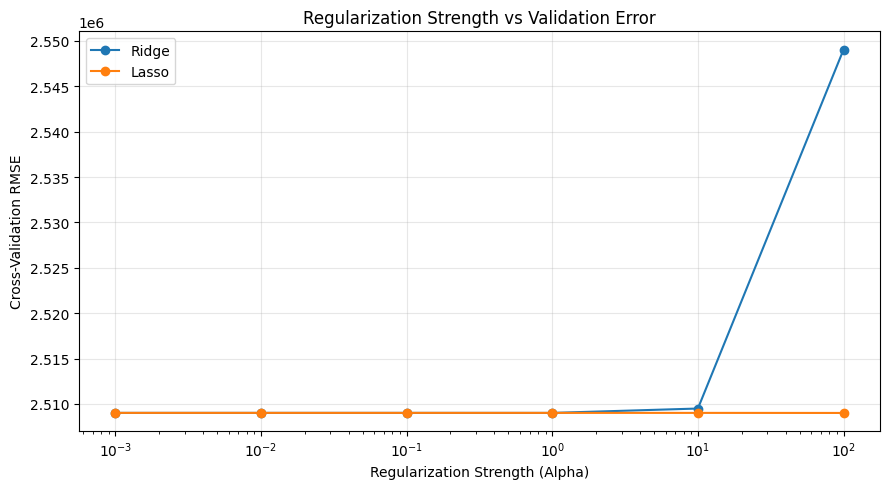

,Feature,Ridge Coefficient,Lasso Coefficient,Lasso_Zero
0,numerical__area_sqft,6.937545e+06,6.944831e+06,False
3,numerical__location_score,3.676865e+06,3.678911e+06,False
4,numerical__property_age,-6.513024e+05,-6.513909e+05,False
1,numerical__bedrooms,2.973655e+05,2.911937e+05,False
2,numerical__bathrooms,2.853268e+05,2.853815e+05,False
8,numerical__crime_rate_index,-1.354728e+05,-1.353088e+05,False
7,numerical__near_metro,5.820432e+04,5.819679e+04,False
5,numerical__distance_city_km,-3.016962e+04,-2.873756e+04,False
6,numerical__near_school,1.697147e+04,1.680345e+04,False


Best Ridge Alpha: 1
Best Lasso Alpha: 100
Ridge Test RMSE: 2558401.736166451
Lasso Test RMSE: 2558145.3237197218
Ridge Test R2: 0.91872594918288
Lasso Test R2: 0.9187422395360456
Lasso coefficients reduced to zero: 0
Lasso achieved the lower test RMSE.
Lasso performed coefficient shrinkage without completely eliminating any feature.


In [6]:
# =============================================================================
# PART C - REGULARIZED LINEAR MODELS
# =============================================================================


# =============================================================================
# Q9 - RIDGE REGRESSION
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Create Ridge Regression Pipeline
# -----------------------------------------------------------------------------

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])


# ------------------------------ STEP 2 ---------------------------------------
# Train Ridge Regression Model
# -----------------------------------------------------------------------------

ridge_pipeline.fit(X_train, y_train)


# ------------------------------ STEP 3 ---------------------------------------
# Generate Ridge Predictions
# -----------------------------------------------------------------------------

ridge_train_predictions = ridge_pipeline.predict(X_train)
ridge_test_predictions = ridge_pipeline.predict(X_test)


# ------------------------------ STEP 4 ---------------------------------------
# Evaluate Ridge Regression
# -----------------------------------------------------------------------------

ridge_train_mse = mean_squared_error(y_train, ridge_train_predictions)
ridge_test_mse = mean_squared_error(y_test, ridge_test_predictions)
ridge_train_mae = mean_absolute_error(y_train, ridge_train_predictions)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_predictions)
ridge_train_rmse = np.sqrt(ridge_train_mse)
ridge_test_rmse = np.sqrt(ridge_test_mse)
ridge_train_r2 = r2_score(y_train, ridge_train_predictions)
ridge_test_r2 = r2_score(y_test, ridge_test_predictions)

ridge_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [ridge_train_mse, ridge_test_mse],
    "MAE": [ridge_train_mae, ridge_test_mae],
    "RMSE": [ridge_train_rmse, ridge_test_rmse],
    "R2": [ridge_train_r2, ridge_test_r2]
})

display(ridge_results)


# =============================================================================
# Q10 - LASSO REGRESSION
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Create Lasso Regression Pipeline
# -----------------------------------------------------------------------------

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=1.0, max_iter=10000))
])


# ------------------------------ STEP 2 ---------------------------------------
# Train Lasso Regression Model
# -----------------------------------------------------------------------------

lasso_pipeline.fit(X_train, y_train)


# ------------------------------ STEP 3 ---------------------------------------
# Generate Lasso Predictions
# -----------------------------------------------------------------------------

lasso_train_predictions = lasso_pipeline.predict(X_train)
lasso_test_predictions = lasso_pipeline.predict(X_test)


# ------------------------------ STEP 4 ---------------------------------------
# Evaluate Lasso Regression
# -----------------------------------------------------------------------------

lasso_train_mse = mean_squared_error(y_train, lasso_train_predictions)
lasso_test_mse = mean_squared_error(y_test, lasso_test_predictions)
lasso_train_mae = mean_absolute_error(y_train, lasso_train_predictions)
lasso_test_mae = mean_absolute_error(y_test, lasso_test_predictions)
lasso_train_rmse = np.sqrt(lasso_train_mse)
lasso_test_rmse = np.sqrt(lasso_test_mse)
lasso_train_r2 = r2_score(y_train, lasso_train_predictions)
lasso_test_r2 = r2_score(y_test, lasso_test_predictions)

lasso_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [lasso_train_mse, lasso_test_mse],
    "MAE": [lasso_train_mae, lasso_test_mae],
    "RMSE": [lasso_train_rmse, lasso_test_rmse],
    "R2": [lasso_train_r2, lasso_test_r2]
})

display(lasso_results)


# =============================================================================
# Q11 - REGULARIZATION HYPERPARAMETER TUNING
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Define Alpha Values for Ridge and Lasso
# -----------------------------------------------------------------------------

alpha_values = {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}


# ------------------------------ STEP 2 ---------------------------------------
# Tune Ridge Alpha Using 5-Fold Cross-Validation
# -----------------------------------------------------------------------------

ridge_search = GridSearchCV(
    ridge_pipeline, alpha_values, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)

ridge_search.fit(X_train, y_train)


# ------------------------------ STEP 3 ---------------------------------------
# Tune Lasso Alpha Using 5-Fold Cross-Validation
# -----------------------------------------------------------------------------

lasso_search = GridSearchCV(
    lasso_pipeline, alpha_values, cv=5,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)

lasso_search.fit(X_train, y_train)


# ------------------------------ STEP 4 ---------------------------------------
# Compare Cross-Validation Performance Across Alpha Values
# -----------------------------------------------------------------------------

ridge_cv_results = pd.DataFrame(ridge_search.cv_results_)
lasso_cv_results = pd.DataFrame(lasso_search.cv_results_)

cols = ["param_model__alpha", "mean_test_score", "std_test_score"]

ridge_alpha_results = ridge_cv_results[cols].copy()
lasso_alpha_results = lasso_cv_results[cols].copy()

ridge_alpha_results["CV_RMSE"] = -ridge_alpha_results["mean_test_score"]
lasso_alpha_results["CV_RMSE"] = -lasso_alpha_results["mean_test_score"]

cols = ["param_model__alpha", "CV_RMSE", "std_test_score"]

ridge_alpha_results = ridge_alpha_results[cols]
lasso_alpha_results = lasso_alpha_results[cols]

ridge_alpha_results.columns = ["Alpha", "CV_RMSE", "CV_RMSE_Std"]
lasso_alpha_results.columns = ["Alpha", "CV_RMSE", "CV_RMSE_Std"]

print("Ridge Cross-Validation Results")
display(ridge_alpha_results)

print("Lasso Cross-Validation Results")
display(lasso_alpha_results)


# =============================================================================
# Q12 - RIDGE VS LASSO COMPARISON
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Compare Training and Validation Error
# -----------------------------------------------------------------------------

best_ridge_model = ridge_search.best_estimator_
best_lasso_model = lasso_search.best_estimator_

best_ridge_alpha = ridge_search.best_params_["model__alpha"]
best_lasso_alpha = lasso_search.best_params_["model__alpha"]

ridge_tuned_train_predictions = best_ridge_model.predict(X_train)
lasso_tuned_train_predictions = best_lasso_model.predict(X_train)

ridge_tuned_test_predictions = best_ridge_model.predict(X_test)
lasso_tuned_test_predictions = best_lasso_model.predict(X_test)

ridge_tuned_train_rmse = np.sqrt(
    mean_squared_error(y_train, ridge_tuned_train_predictions)
)

lasso_tuned_train_rmse = np.sqrt(
    mean_squared_error(y_train, lasso_tuned_train_predictions)
)

ridge_validation_rmse = -ridge_search.best_score_
lasso_validation_rmse = -lasso_search.best_score_

validation_comparison = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression"],
    "Best Alpha": [best_ridge_alpha, best_lasso_alpha],
    "Training RMSE": [
        ridge_tuned_train_rmse,
        lasso_tuned_train_rmse
    ],
    "Validation RMSE": [
        ridge_validation_rmse,
        lasso_validation_rmse
    ]
})

display(validation_comparison)


# ------------------------------ STEP 2 ---------------------------------------
# Visualize Validation Error Across Regularization Strength
# -----------------------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    ridge_alpha_results["Alpha"],
    ridge_alpha_results["CV_RMSE"],
    marker="o", label="Ridge"
)

plt.plot(
    lasso_alpha_results["Alpha"],
    lasso_alpha_results["CV_RMSE"],
    marker="o", label="Lasso"
)

plt.xscale("log")
plt.xlabel("Regularization Strength (Alpha)")
plt.ylabel("Cross-Validation RMSE")
plt.title("Regularization Strength vs Validation Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------ STEP 3 ---------------------------------------
# Compare Ridge and Lasso Coefficients
# -----------------------------------------------------------------------------

ridge_coefficients = best_ridge_model.named_steps["model"].coef_
lasso_coefficients = best_lasso_model.named_steps["model"].coef_

feature_names = (
    best_ridge_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficient_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Ridge Coefficient": ridge_coefficients,
    "Lasso Coefficient": lasso_coefficients
})

coefficient_comparison["Lasso_Zero"] = np.isclose(
    coefficient_comparison["Lasso Coefficient"], 0
)

coefficient_comparison = coefficient_comparison.sort_values(
    "Ridge Coefficient", key=np.abs, ascending=False
)

display(coefficient_comparison)


# ------------------------------ STEP 4 ---------------------------------------
# Analyze Regularization and Model Performance
# -----------------------------------------------------------------------------

ridge_final_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_tuned_test_predictions)
)

lasso_final_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_tuned_test_predictions)
)

ridge_final_r2 = r2_score(y_test, ridge_tuned_test_predictions)
lasso_final_r2 = r2_score(y_test, lasso_tuned_test_predictions)

zero_coefficients = coefficient_comparison["Lasso_Zero"].sum()

print("Best Ridge Alpha:", best_ridge_alpha)
print("Best Lasso Alpha:", best_lasso_alpha)
print("Ridge Test RMSE:", ridge_final_rmse)
print("Lasso Test RMSE:", lasso_final_rmse)
print("Ridge Test R2:", ridge_final_r2)
print("Lasso Test R2:", lasso_final_r2)
print("Lasso coefficients reduced to zero:", zero_coefficients)

if lasso_final_rmse < ridge_final_rmse:
    print("Lasso achieved the lower test RMSE.")
else:
    print("Ridge achieved the lower test RMSE.")

if zero_coefficients == 0:
    print("Lasso performed coefficient shrinkage without completely eliminating any feature.")
else:
    print("Lasso performed feature selection by reducing some coefficients completely to zero.")

,CV Strategy,MSE,MAE,RMSE,R2
0,K-Fold,6.315941e+12,1.920806e+06,2.511687e+06,0.915225
1,Stratified K-Fold,6.299673e+12,1.919597e+06,2.508705e+06,0.915547
2,Leave-One-Out,6.298373e+12,1.918461e+06,2.509656e+06,0.915578
3,Time Series Split,6.317813e+12,1.926650e+06,2.511495e+06,0.915071


,CV Strategy,RMSE Std,R2 Std
0,K-Fold,85848.757900,0.004359
1,Stratified K-Fold,77928.681591,0.004178
2,Time Series Split,101015.777809,0.005979


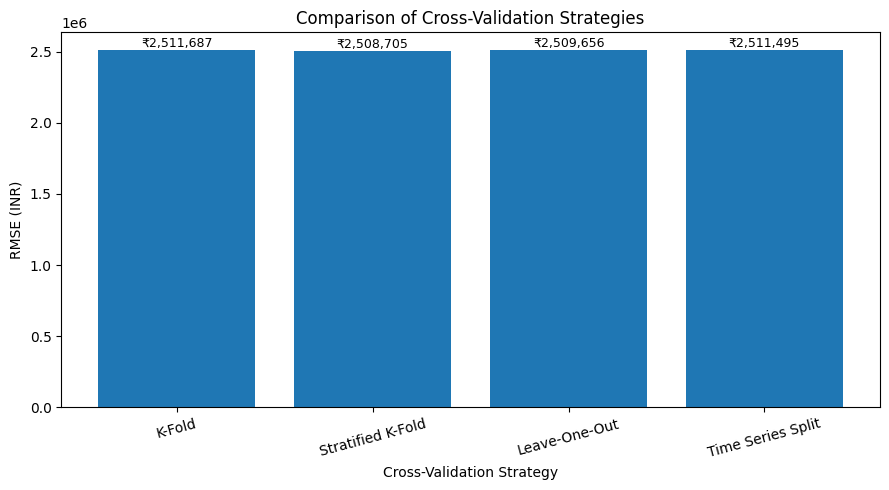

Lowest Overall RMSE: Stratified K-Fold
Most Stable CV Strategy: Stratified K-Fold


In [7]:
# =============================================================================
# PART D - CROSS-VALIDATION STRATEGIES
# =============================================================================


# =============================================================================
# Q13 - APPLY AND COMPARE CROSS-VALIDATION TECHNIQUES
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Apply K-Fold Cross-Validation
# -----------------------------------------------------------------------------

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_results = cross_validate(
    best_lasso_model, X_train, y_train, cv=kfold,
    scoring={
        "MSE": "neg_mean_squared_error",
        "MAE": "neg_mean_absolute_error",
        "R2": "r2"
    },
    n_jobs=-1
)

kfold_mse = -kfold_results["test_MSE"]
kfold_mae = -kfold_results["test_MAE"]
kfold_rmse = np.sqrt(kfold_mse)
kfold_r2 = kfold_results["test_R2"]


# ------------------------------ STEP 2 ---------------------------------------
# Apply Stratified K-Fold by Binning Target Values
# -----------------------------------------------------------------------------

target_bins = pd.qcut(y_train, q=5, labels=False, duplicates="drop")

stratified_kfold = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)

stratified_results = cross_validate(
    best_lasso_model, X_train, y_train,
    cv=stratified_kfold.split(X_train, target_bins),
    scoring={
        "MSE": "neg_mean_squared_error",
        "MAE": "neg_mean_absolute_error",
        "R2": "r2"
    },
    n_jobs=-1
)

stratified_mse = -stratified_results["test_MSE"]
stratified_mae = -stratified_results["test_MAE"]
stratified_rmse = np.sqrt(stratified_mse)
stratified_r2 = stratified_results["test_R2"]


# ------------------------------ STEP 3 ---------------------------------------
# Apply Leave-One-Out Cross-Validation
# -----------------------------------------------------------------------------

loo = LeaveOneOut()

loo_predictions = cross_val_predict(
    best_lasso_model, X_train, y_train, cv=loo, n_jobs=-1
)

loo_mse = mean_squared_error(y_train, loo_predictions)
loo_mae = mean_absolute_error(y_train, loo_predictions)
loo_rmse = np.sqrt(loo_mse)
loo_r2 = r2_score(y_train, loo_predictions)


# ------------------------------ STEP 4 ---------------------------------------
# Apply Time Series Split Using Sale Date
# -----------------------------------------------------------------------------

time_data = df.loc[
    X_train.index,
    [
        "sale_date", "area_sqft", "bedrooms", "bathrooms",
        "location_score", "property_age", "distance_city_km",
        "near_school", "near_metro", "crime_rate_index", TARGET
    ]
].copy()

time_data = time_data.sort_values("sale_date").reset_index(drop=True)

X_time = time_data.drop(columns=["sale_date", TARGET])
y_time = time_data[TARGET]

time_series_split = TimeSeriesSplit(n_splits=5)

time_results = cross_validate(
    best_lasso_model, X_time, y_time, cv=time_series_split,
    scoring={
        "MSE": "neg_mean_squared_error",
        "MAE": "neg_mean_absolute_error",
        "R2": "r2"
    },
    n_jobs=-1
)

time_mse = -time_results["test_MSE"]
time_mae = -time_results["test_MAE"]
time_rmse = np.sqrt(time_mse)
time_r2 = time_results["test_R2"]


# =============================================================================
# Q14 - ANALYZE PERFORMANCE ACROSS CV STRATEGIES
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Compare Overall Cross-Validation Performance
# -----------------------------------------------------------------------------

cv_comparison = pd.DataFrame({
    "CV Strategy": [
        "K-Fold", "Stratified K-Fold",
        "Leave-One-Out", "Time Series Split"
    ],
    "MSE": [
        kfold_mse.mean(), stratified_mse.mean(),
        loo_mse, time_mse.mean()
    ],
    "MAE": [
        kfold_mae.mean(), stratified_mae.mean(),
        loo_mae, time_mae.mean()
    ],
    "RMSE": [
        kfold_rmse.mean(), stratified_rmse.mean(),
        loo_rmse, time_rmse.mean()
    ],
    "R2": [
        kfold_r2.mean(), stratified_r2.mean(),
        loo_r2, time_r2.mean()
    ]
})

display(cv_comparison)


# ------------------------------ STEP 2 ---------------------------------------
# Analyze Performance Variation Across Folds
# -----------------------------------------------------------------------------

cv_stability = pd.DataFrame({
    "CV Strategy": [
        "K-Fold", "Stratified K-Fold", "Time Series Split"
    ],
    "RMSE Std": [
        kfold_rmse.std(), stratified_rmse.std(), time_rmse.std()
    ],
    "R2 Std": [
        kfold_r2.std(), stratified_r2.std(), time_r2.std()
    ]
})

display(cv_stability)


# ------------------------------ STEP 3 ---------------------------------------
# Visualize RMSE Across Cross-Validation Strategies
# -----------------------------------------------------------------------------

plt.figure(figsize=(9, 5))

bars = plt.bar(cv_comparison["CV Strategy"], cv_comparison["RMSE"])

plt.xlabel("Cross-Validation Strategy")
plt.ylabel("RMSE (INR)")
plt.title("Comparison of Cross-Validation Strategies")
plt.xticks(rotation=15)

for bar, value in zip(bars, cv_comparison["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ------------------------------ STEP 4 ---------------------------------------
# Identify Best and Most Stable CV Strategy
# -----------------------------------------------------------------------------

best_cv_index = cv_comparison["RMSE"].idxmin()
best_cv_strategy = cv_comparison.loc[best_cv_index, "CV Strategy"]

stable_cv_index = cv_stability["RMSE Std"].idxmin()
stable_cv_strategy = cv_stability.loc[stable_cv_index, "CV Strategy"]

print("Lowest Overall RMSE:", best_cv_strategy)
print("Most Stable CV Strategy:", stable_cv_strategy)

,Dataset,MSE,MAE,RMSE,R2
0,Training,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
1,Testing,1.141862e+13,2.480762e+06,3.379145e+06,0.858216


Best Decision Tree Parameters: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Decision Tree CV RMSE: 2765494.928980239


,Dataset,RMSE,R2
0,Training,2.203180e+06,0.934938
1,Testing,2.769337e+06,0.904772


,Dataset,MSE,MAE,RMSE,R2
0,Training,7.876713e+11,6.566788e+05,8.875085e+05,0.989442
1,Testing,5.802085e+12,1.772057e+06,2.408752e+06,0.927956


,Model,Test RMSE,Test MAE,Test R2
0,Decision Tree,3.379145e+06,2.480762e+06,0.858216
1,Tuned Decision Tree,2.769337e+06,2.013210e+06,0.904772
2,Random Forest,2.408752e+06,1.772057e+06,0.927956


,Model,Training RMSE,Testing RMSE,Training R2,Testing R2
0,Decision Tree,0.000000e+00,3.379145e+06,1.000000,0.858216
1,Tuned Decision Tree,2.203180e+06,2.769337e+06,0.934938,0.904772
2,Random Forest,8.875085e+05,2.408752e+06,0.989442,0.927956


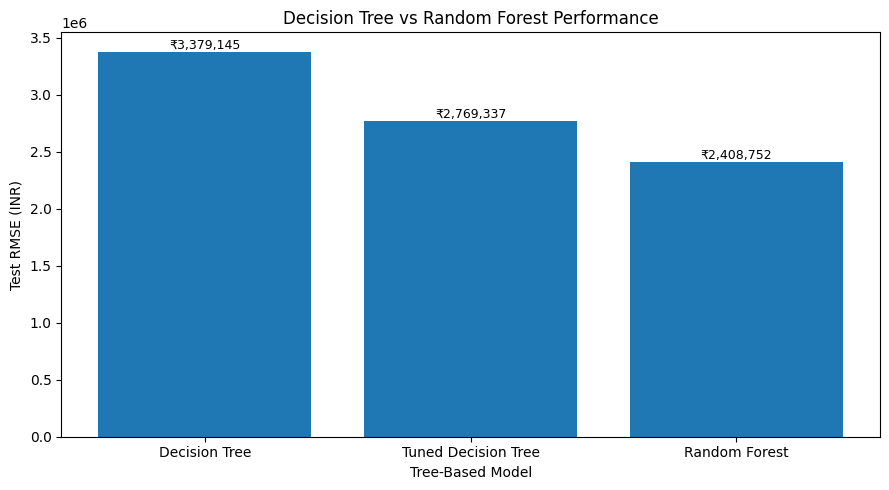

Best Tree-Based Model: Random Forest
Best Test RMSE: ₹2,408,751.74
Best Test R2: 0.9280


In [8]:
# =============================================================================
# PART E - TREE-BASED REGRESSION MODELS
# =============================================================================


# =============================================================================
# Q15 - DECISION TREE REGRESSION
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Create Decision Tree Regression Model
# -----------------------------------------------------------------------------

decision_tree = DecisionTreeRegressor(random_state=42)


# ------------------------------ STEP 2 ---------------------------------------
# Train Decision Tree Regression Model
# -----------------------------------------------------------------------------

decision_tree.fit(X_train, y_train)


# ------------------------------ STEP 3 ---------------------------------------
# Generate Decision Tree Predictions
# -----------------------------------------------------------------------------

decision_tree_train_predictions = decision_tree.predict(X_train)
decision_tree_test_predictions = decision_tree.predict(X_test)


# ------------------------------ STEP 4 ---------------------------------------
# Evaluate Decision Tree Regression
# -----------------------------------------------------------------------------

decision_tree_train_mse = mean_squared_error(y_train, decision_tree_train_predictions)
decision_tree_test_mse = mean_squared_error(y_test, decision_tree_test_predictions)

decision_tree_train_mae = mean_absolute_error(y_train, decision_tree_train_predictions)
decision_tree_test_mae = mean_absolute_error(y_test, decision_tree_test_predictions)

decision_tree_train_rmse = np.sqrt(decision_tree_train_mse)
decision_tree_test_rmse = np.sqrt(decision_tree_test_mse)

decision_tree_train_r2 = r2_score(y_train, decision_tree_train_predictions)
decision_tree_test_r2 = r2_score(y_test, decision_tree_test_predictions)

decision_tree_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [decision_tree_train_mse, decision_tree_test_mse],
    "MAE": [decision_tree_train_mae, decision_tree_test_mae],
    "RMSE": [decision_tree_train_rmse, decision_tree_test_rmse],
    "R2": [decision_tree_train_r2, decision_tree_test_r2]
})

display(decision_tree_results)


# =============================================================================
# Q16 - CONTROL DECISION TREE COMPLEXITY
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Define Decision Tree Complexity Parameters
# -----------------------------------------------------------------------------

tree_parameters = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}


# ------------------------------ STEP 2 ---------------------------------------
# Tune Decision Tree Parameters Using Cross-Validation
# -----------------------------------------------------------------------------

tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_parameters,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

tree_search.fit(X_train, y_train)


# ------------------------------ STEP 3 ---------------------------------------
# Identify Best Decision Tree Parameters
# -----------------------------------------------------------------------------

best_tree_model = tree_search.best_estimator_
best_tree_parameters = tree_search.best_params_
best_tree_cv_rmse = -tree_search.best_score_

print("Best Decision Tree Parameters:", best_tree_parameters)
print("Best Decision Tree CV RMSE:", best_tree_cv_rmse)


# ------------------------------ STEP 4 ---------------------------------------
# Evaluate Tuned Decision Tree
# -----------------------------------------------------------------------------

tuned_tree_train_predictions = best_tree_model.predict(X_train)
tuned_tree_test_predictions = best_tree_model.predict(X_test)

tuned_tree_train_rmse = np.sqrt(
    mean_squared_error(y_train, tuned_tree_train_predictions)
)

tuned_tree_test_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_tree_test_predictions)
)

tuned_tree_train_r2 = r2_score(y_train, tuned_tree_train_predictions)
tuned_tree_test_r2 = r2_score(y_test, tuned_tree_test_predictions)

tuned_tree_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "RMSE": [tuned_tree_train_rmse, tuned_tree_test_rmse],
    "R2": [tuned_tree_train_r2, tuned_tree_test_r2]
})

display(tuned_tree_results)


# =============================================================================
# Q17 - RANDOM FOREST REGRESSION
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Create Random Forest Regression Model
# -----------------------------------------------------------------------------

random_forest = RandomForestRegressor(
    n_estimators=200, random_state=42, n_jobs=-1
)


# ------------------------------ STEP 2 ---------------------------------------
# Train Random Forest Regression Model
# -----------------------------------------------------------------------------

random_forest.fit(X_train, y_train)


# ------------------------------ STEP 3 ---------------------------------------
# Generate Random Forest Predictions
# -----------------------------------------------------------------------------

random_forest_train_predictions = random_forest.predict(X_train)
random_forest_test_predictions = random_forest.predict(X_test)


# ------------------------------ STEP 4 ---------------------------------------
# Evaluate Random Forest Regression
# -----------------------------------------------------------------------------

random_forest_train_mse = mean_squared_error(
    y_train, random_forest_train_predictions
)

random_forest_test_mse = mean_squared_error(
    y_test, random_forest_test_predictions
)

random_forest_train_mae = mean_absolute_error(
    y_train, random_forest_train_predictions
)

random_forest_test_mae = mean_absolute_error(
    y_test, random_forest_test_predictions
)

random_forest_train_rmse = np.sqrt(random_forest_train_mse)
random_forest_test_rmse = np.sqrt(random_forest_test_mse)

random_forest_train_r2 = r2_score(
    y_train, random_forest_train_predictions
)

random_forest_test_r2 = r2_score(
    y_test, random_forest_test_predictions
)

random_forest_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [random_forest_train_mse, random_forest_test_mse],
    "MAE": [random_forest_train_mae, random_forest_test_mae],
    "RMSE": [random_forest_train_rmse, random_forest_test_rmse],
    "R2": [random_forest_train_r2, random_forest_test_r2]
})

display(random_forest_results)


# =============================================================================
# Q18 - COMPARE DECISION TREE AND RANDOM FOREST
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Create Tree-Based Model Comparison
# -----------------------------------------------------------------------------

tree_model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest"
    ],
    "Test RMSE": [
        decision_tree_test_rmse,
        tuned_tree_test_rmse,
        random_forest_test_rmse
    ],
    "Test MAE": [
        decision_tree_test_mae,
        mean_absolute_error(y_test, tuned_tree_test_predictions),
        random_forest_test_mae
    ],
    "Test R2": [
        decision_tree_test_r2,
        tuned_tree_test_r2,
        random_forest_test_r2
    ]
})

display(tree_model_comparison)


# ------------------------------ STEP 2 ---------------------------------------
# Compare Training and Testing Performance
# -----------------------------------------------------------------------------

tree_generalization = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest"
    ],
    "Training RMSE": [
        decision_tree_train_rmse,
        tuned_tree_train_rmse,
        random_forest_train_rmse
    ],
    "Testing RMSE": [
        decision_tree_test_rmse,
        tuned_tree_test_rmse,
        random_forest_test_rmse
    ],
    "Training R2": [
        decision_tree_train_r2,
        tuned_tree_train_r2,
        random_forest_train_r2
    ],
    "Testing R2": [
        decision_tree_test_r2,
        tuned_tree_test_r2,
        random_forest_test_r2
    ]
})

display(tree_generalization)


# ------------------------------ STEP 3 ---------------------------------------
# Visualize Tree-Based Model Performance
# -----------------------------------------------------------------------------

plt.figure(figsize=(9, 5))

bars = plt.bar(
    tree_model_comparison["Model"],
    tree_model_comparison["Test RMSE"]
)

plt.xlabel("Tree-Based Model")
plt.ylabel("Test RMSE (INR)")
plt.title("Decision Tree vs Random Forest Performance")

for bar, value in zip(bars, tree_model_comparison["Test RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ------------------------------ STEP 4 ---------------------------------------
# Identify Best Tree-Based Model and Summarize Generalization
# -----------------------------------------------------------------------------

best_tree_index = tree_model_comparison["Test RMSE"].idxmin()

best_tree_based_model = tree_model_comparison.loc[
    best_tree_index, "Model"
]

best_tree_based_rmse = tree_model_comparison.loc[
    best_tree_index, "Test RMSE"
]

best_tree_based_r2 = tree_model_comparison.loc[
    best_tree_index, "Test R2"
]

print("Best Tree-Based Model:", best_tree_based_model)
print(f"Best Test RMSE: ₹{best_tree_based_rmse:,.2f}")
print(f"Best Test R2: {best_tree_based_r2:.4f}")

,Kernel,MSE,MAE,RMSE,R2
0,Linear,8.068929e+13,6.990272e+06,8.982722e+06,-0.001914
1,Polynomial,8.076769e+13,6.993875e+06,8.987085e+06,-0.002887
2,RBF,8.077204e+13,6.994024e+06,8.987327e+06,-0.002941


Best SVR Parameters: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__kernel': 'linear'}
Best SVR CV RMSE: ₹8,292,518.88


,Dataset,MSE,MAE,RMSE,R2
0,Training,6.733807e+13,6.466055e+06,8.205978e+06,0.097414
1,Testing,7.261791e+13,6.620813e+06,8.521614e+06,0.098308


,Model,Test RMSE,Test MAE,Test R2
0,Linear SVR,8.982722e+06,6.990272e+06,-0.001914
1,Polynomial SVR,8.987085e+06,6.993875e+06,-0.002887
2,RBF SVR,8.987327e+06,6.994024e+06,-0.002941
3,Tuned SVR,8.521614e+06,6.620813e+06,0.098308


Best SVR Kernel Before Tuning: Linear
Kernel Test RMSE: ₹8,982,721.79
Kernel Test R2: -0.0019


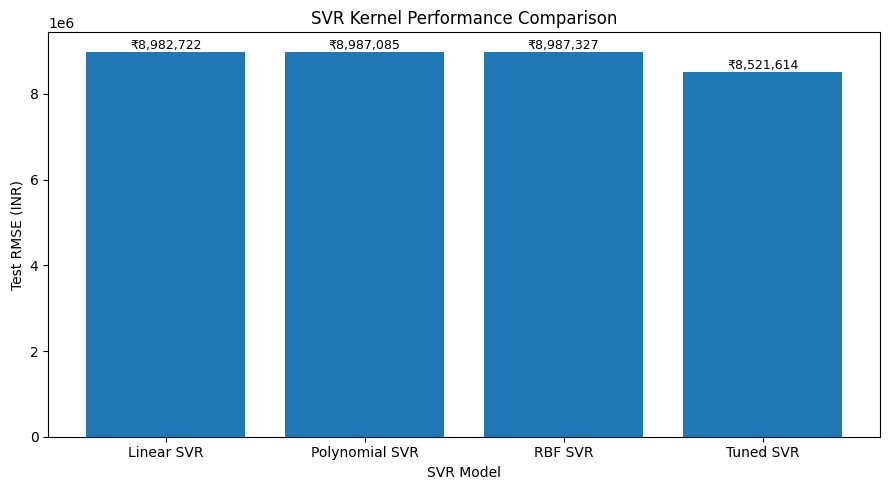

Best Overall SVR Model: Tuned SVR
Best SVR Test RMSE: ₹8,521,614.19
Best SVR Test R2: 0.0983


In [9]:
# =============================================================================
# PART F - SUPPORT VECTOR REGRESSION
# =============================================================================


# =============================================================================
# Q19 - APPLY SVR WITH DIFFERENT KERNELS
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Create SVR Models with Linear, Polynomial and RBF Kernels
# -----------------------------------------------------------------------------

svr_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="linear"))
])

svr_polynomial = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="poly"))
])

svr_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])


# ------------------------------ STEP 2 ---------------------------------------
# Train SVR Models
# -----------------------------------------------------------------------------

svr_linear.fit(X_train, y_train)
svr_polynomial.fit(X_train, y_train)
svr_rbf.fit(X_train, y_train)


# ------------------------------ STEP 3 ---------------------------------------
# Generate Predictions for Each SVR Kernel
# -----------------------------------------------------------------------------

svr_linear_predictions = svr_linear.predict(X_test)
svr_polynomial_predictions = svr_polynomial.predict(X_test)
svr_rbf_predictions = svr_rbf.predict(X_test)


# ------------------------------ STEP 4 ---------------------------------------
# Evaluate SVR Kernel Performance
# -----------------------------------------------------------------------------

predictions = [
    svr_linear_predictions,
    svr_polynomial_predictions,
    svr_rbf_predictions
]

svr_kernel_results = pd.DataFrame({
    "Kernel": ["Linear", "Polynomial", "RBF"],
    "MSE": [mean_squared_error(y_test, p) for p in predictions],
    "MAE": [mean_absolute_error(y_test, p) for p in predictions],
    "RMSE": [np.sqrt(mean_squared_error(y_test, p)) for p in predictions],
    "R2": [r2_score(y_test, p) for p in predictions]
})

display(svr_kernel_results)


# =============================================================================
# Q20 - TUNE SVR HYPERPARAMETERS
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Define SVR Hyperparameter Grid
# -----------------------------------------------------------------------------

svr_parameters = [
    {
        "svr__kernel": ["linear"],
        "svr__C": [0.1, 1, 10, 100],
        "svr__epsilon": [0.01, 0.1, 1]
    },
    {
        "svr__kernel": ["poly"],
        "svr__C": [0.1, 1, 10, 100],
        "svr__degree": [2, 3, 4],
        "svr__gamma": ["scale", "auto"],
        "svr__epsilon": [0.01, 0.1, 1]
    },
    {
        "svr__kernel": ["rbf"],
        "svr__C": [0.1, 1, 10, 100],
        "svr__gamma": ["scale", "auto"],
        "svr__epsilon": [0.01, 0.1, 1]
    }
]


# ------------------------------ STEP 2 ---------------------------------------
# Perform Grid Search with Cross-Validation
# -----------------------------------------------------------------------------

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

svr_search = GridSearchCV(
    svr_pipeline,
    svr_parameters,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

svr_search.fit(X_train, y_train)


# ------------------------------ STEP 3 ---------------------------------------
# Identify Best SVR Configuration
# -----------------------------------------------------------------------------

best_svr_model = svr_search.best_estimator_
best_svr_parameters = svr_search.best_params_
best_svr_cv_rmse = -svr_search.best_score_

print("Best SVR Parameters:", best_svr_parameters)
print(f"Best SVR CV RMSE: ₹{best_svr_cv_rmse:,.2f}")


# ------------------------------ STEP 4 ---------------------------------------
# Evaluate Tuned SVR Model
# -----------------------------------------------------------------------------

best_svr_train_predictions = best_svr_model.predict(X_train)
best_svr_test_predictions = best_svr_model.predict(X_test)

best_svr_train_mse = mean_squared_error(
    y_train, best_svr_train_predictions
)

best_svr_test_mse = mean_squared_error(
    y_test, best_svr_test_predictions
)

best_svr_train_mae = mean_absolute_error(
    y_train, best_svr_train_predictions
)

best_svr_test_mae = mean_absolute_error(
    y_test, best_svr_test_predictions
)

best_svr_train_rmse = np.sqrt(best_svr_train_mse)
best_svr_test_rmse = np.sqrt(best_svr_test_mse)

best_svr_train_r2 = r2_score(y_train, best_svr_train_predictions)
best_svr_test_r2 = r2_score(y_test, best_svr_test_predictions)

best_svr_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MSE": [best_svr_train_mse, best_svr_test_mse],
    "MAE": [best_svr_train_mae, best_svr_test_mae],
    "RMSE": [best_svr_train_rmse, best_svr_test_rmse],
    "R2": [best_svr_train_r2, best_svr_test_r2]
})

display(best_svr_results)


# =============================================================================
# Q21 - COMPARE SVR KERNELS AND TUNED MODEL
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Create SVR Model Comparison
# -----------------------------------------------------------------------------

kernel_names = ["Linear", "Polynomial", "RBF"]
kernel_models = [
    svr_linear_predictions,
    svr_polynomial_predictions,
    svr_rbf_predictions
]

svr_comparison = pd.DataFrame({
    "Model": ["Linear SVR", "Polynomial SVR", "RBF SVR", "Tuned SVR"],
    "Test RMSE": [
        *[np.sqrt(mean_squared_error(y_test, p)) for p in kernel_models],
        best_svr_test_rmse
    ],
    "Test MAE": [
        *[mean_absolute_error(y_test, p) for p in kernel_models],
        best_svr_test_mae
    ],
    "Test R2": [
        *[r2_score(y_test, p) for p in kernel_models],
        best_svr_test_r2
    ]
})

display(svr_comparison)


# ------------------------------ STEP 2 ---------------------------------------
# Identify Best SVR Kernel Before Tuning
# -----------------------------------------------------------------------------

best_kernel_index = svr_kernel_results["RMSE"].idxmin()

best_kernel = svr_kernel_results.loc[best_kernel_index, "Kernel"]
best_kernel_rmse = svr_kernel_results.loc[best_kernel_index, "RMSE"]
best_kernel_r2 = svr_kernel_results.loc[best_kernel_index, "R2"]

print("Best SVR Kernel Before Tuning:", best_kernel)
print(f"Kernel Test RMSE: ₹{best_kernel_rmse:,.2f}")
print(f"Kernel Test R2: {best_kernel_r2:.4f}")


# ------------------------------ STEP 3 ---------------------------------------
# Visualize SVR Kernel Performance
# -----------------------------------------------------------------------------

plt.figure(figsize=(9, 5))

bars = plt.bar(
    svr_comparison["Model"],
    svr_comparison["Test RMSE"]
)

plt.xlabel("SVR Model")
plt.ylabel("Test RMSE (INR)")
plt.title("SVR Kernel Performance Comparison")

for bar, value in zip(bars, svr_comparison["Test RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ------------------------------ STEP 4 ---------------------------------------
# Identify and Summarize Final SVR Performance
# -----------------------------------------------------------------------------

best_svr_comparison_index = svr_comparison["Test RMSE"].idxmin()

final_svr_model = svr_comparison.loc[
    best_svr_comparison_index, "Model"
]

final_svr_rmse = svr_comparison.loc[
    best_svr_comparison_index, "Test RMSE"
]

final_svr_r2 = svr_comparison.loc[
    best_svr_comparison_index, "Test R2"
]

print("Best Overall SVR Model:", final_svr_model)
print(f"Best SVR Test RMSE: ₹{final_svr_rmse:,.2f}")
print(f"Best SVR Test R2: {final_svr_r2:.4f}")

,Model,Test RMSE,Test MAE,Test R2
0,Ridge Regression,2.558402e+06,1.959199e+06,0.918726
1,Lasso Regression,2.558124e+06,1.959378e+06,0.918744
2,Decision Tree,3.379145e+06,2.480762e+06,0.858216
3,Tuned Decision Tree,2.769337e+06,2.013210e+06,0.904772
4,Random Forest,2.408752e+06,1.772057e+06,0.927956
5,Tuned SVR,8.521614e+06,6.620813e+06,0.098308


,Rank,Model,Test RMSE,Test MAE,Test R2
0,1,Random Forest,2.408752e+06,1.772057e+06,0.927956
1,2,Lasso Regression,2.558124e+06,1.959378e+06,0.918744
2,3,Ridge Regression,2.558402e+06,1.959199e+06,0.918726
3,4,Tuned Decision Tree,2.769337e+06,2.013210e+06,0.904772
4,5,Decision Tree,3.379145e+06,2.480762e+06,0.858216
5,6,Tuned SVR,8.521614e+06,6.620813e+06,0.098308


Best Overall Model: Random Forest
Test RMSE: ₹2,408,751.74
Test MAE: ₹1,772,057.16
Test R2: 0.9280


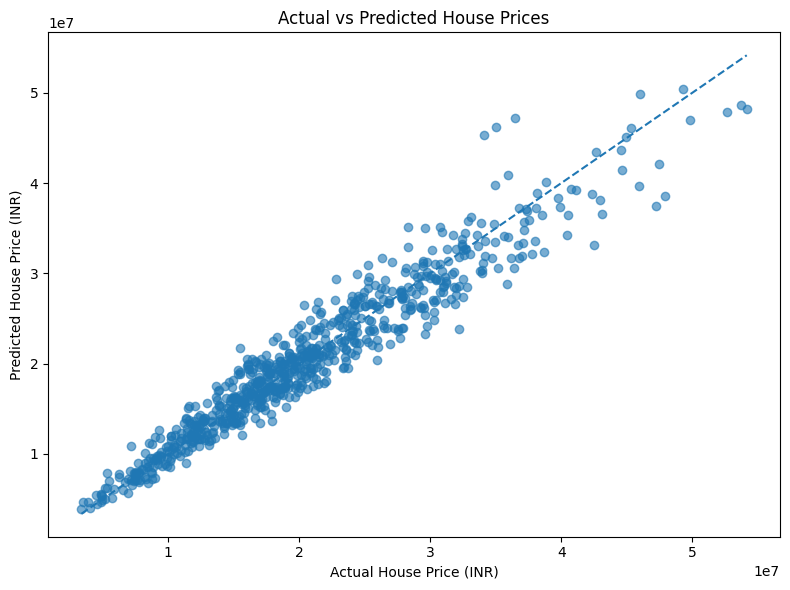

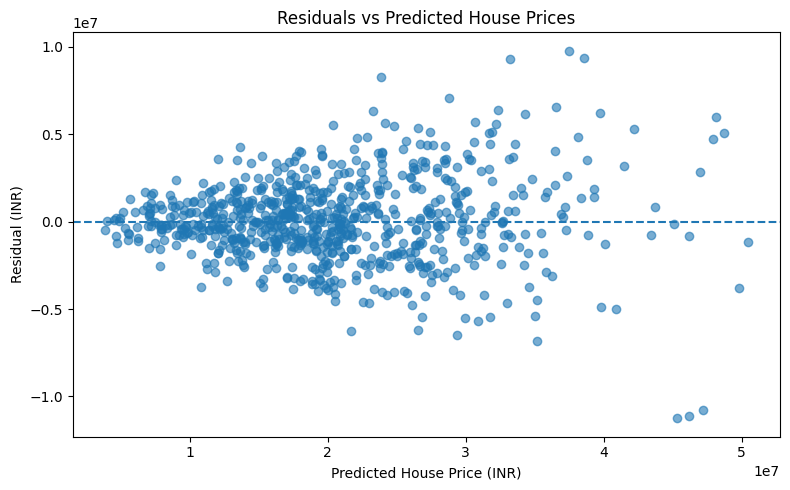

Mean Residual: ₹67,913.39
Mean Absolute Error: ₹1,772,057.16
Residual Standard Deviation: ₹2,407,794.16


,Model,Training R2,Testing R2
0,Ridge Regression,0.916185,0.918726
1,Lasso Regression,0.916186,0.918744
2,Decision Tree,1.000000,0.858216
3,Tuned Decision Tree,0.934938,0.904772
4,Random Forest,0.989442,0.927956
5,Tuned SVR,0.097414,0.098308


,Model,Training R2,Testing R2,R2 Gap
0,Ridge Regression,0.916185,0.918726,-0.002541
1,Lasso Regression,0.916186,0.918744,-0.002558
2,Decision Tree,1.000000,0.858216,0.141784
3,Tuned Decision Tree,0.934938,0.904772,0.030166
4,Random Forest,0.989442,0.927956,0.061486
5,Tuned SVR,0.097414,0.098308,-0.000894


,Model,Training R2,Testing R2,R2 Gap,Model Behavior
0,Ridge Regression,0.916185,0.918726,-0.002541,Good Generalization
1,Lasso Regression,0.916186,0.918744,-0.002558,Good Generalization
2,Decision Tree,1.000000,0.858216,0.141784,Overfitting
3,Tuned Decision Tree,0.934938,0.904772,0.030166,Good Generalization
4,Random Forest,0.989442,0.927956,0.061486,Good Generalization
5,Tuned SVR,0.097414,0.098308,-0.000894,Underfitting


Final Model: Random Forest
Final Test RMSE: ₹2,408,751.74
Final Test MAE: ₹1,772,057.16
Final Test R2: 0.9280


In [10]:
# =============================================================================
# PART G - FINAL MODEL EVALUATION
# =============================================================================


# =============================================================================
# Q22 - FINAL MODEL COMPARISON
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Compare All Developed Models
# -----------------------------------------------------------------------------

final_models = pd.DataFrame({
    "Model": [
        "Ridge Regression", "Lasso Regression", "Decision Tree",
        "Tuned Decision Tree", "Random Forest", "Tuned SVR"
    ],
    "Test RMSE": [
        ridge_test_rmse, lasso_test_rmse, decision_tree_test_rmse,
        tuned_tree_test_rmse, random_forest_test_rmse, best_svr_test_rmse
    ],
    "Test MAE": [
        ridge_test_mae, lasso_test_mae, decision_tree_test_mae,
        2.013210e+06, random_forest_test_mae, best_svr_test_mae
    ],
    "Test R2": [
        ridge_test_r2, lasso_test_r2, decision_tree_test_r2,
        tuned_tree_test_r2, random_forest_test_r2, best_svr_test_r2
    ]
})

display(final_models)


# ------------------------------ STEP 2 ---------------------------------------
# Rank Models by Test RMSE
# -----------------------------------------------------------------------------

final_ranking = final_models.sort_values(
    "Test RMSE"
).reset_index(drop=True)

final_ranking.insert(0, "Rank", range(1, len(final_ranking) + 1))

display(final_ranking)


# ------------------------------ STEP 3 ---------------------------------------
# Identify the Best Overall Model
# -----------------------------------------------------------------------------

best_index = final_models["Test RMSE"].idxmin()

best_model = final_models.loc[best_index, "Model"]
best_rmse = final_models.loc[best_index, "Test RMSE"]
best_mae = final_models.loc[best_index, "Test MAE"]
best_r2 = final_models.loc[best_index, "Test R2"]


# ------------------------------ STEP 4 ---------------------------------------
# Display Final Model Performance
# -----------------------------------------------------------------------------

print("Best Overall Model:", best_model)
print(f"Test RMSE: ₹{best_rmse:,.2f}")
print(f"Test MAE: ₹{best_mae:,.2f}")
print(f"Test R2: {best_r2:.4f}")


# =============================================================================
# Q23 - ACTUAL VS PREDICTED AND RESIDUAL ANALYSIS
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Generate Predictions Using the Best Model
# -----------------------------------------------------------------------------

final_predictions = random_forest_test_predictions
residuals = y_test.values - final_predictions


# ------------------------------ STEP 2 ---------------------------------------
# Plot Actual vs Predicted Prices
# -----------------------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(y_test, final_predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Price (INR)")
plt.ylabel("Predicted House Price (INR)")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()


# ------------------------------ STEP 3 ---------------------------------------
# Plot Prediction Residuals
# -----------------------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(final_predictions, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted House Price (INR)")
plt.ylabel("Residual (INR)")
plt.title("Residuals vs Predicted House Prices")
plt.tight_layout()
plt.show()


# ------------------------------ STEP 4 ---------------------------------------
# Summarize Prediction Errors
# -----------------------------------------------------------------------------

print(f"Mean Residual: ₹{np.mean(residuals):,.2f}")
print(f"Mean Absolute Error: ₹{np.mean(np.abs(residuals)):,.2f}")
print(f"Residual Standard Deviation: ₹{np.std(residuals):,.2f}")


# =============================================================================
# Q24 - OVERFITTING ANALYSIS AND FINAL CONCLUSION
# =============================================================================


# ------------------------------ STEP 1 ---------------------------------------
# Compare Training and Testing Performance
# -----------------------------------------------------------------------------

generalization = pd.DataFrame({
    "Model": [
        "Ridge Regression", "Lasso Regression", "Decision Tree",
        "Tuned Decision Tree", "Random Forest", "Tuned SVR"
    ],
    "Training R2": [
        ridge_train_r2, lasso_train_r2, decision_tree_train_r2,
        tuned_tree_train_r2, random_forest_train_r2, best_svr_train_r2
    ],
    "Testing R2": [
        ridge_test_r2, lasso_test_r2, decision_tree_test_r2,
        tuned_tree_test_r2, random_forest_test_r2, best_svr_test_r2
    ]
})

display(generalization)


# ------------------------------ STEP 2 ---------------------------------------
# Calculate R2 Generalization Gap
# -----------------------------------------------------------------------------

generalization["R2 Gap"] = (
    generalization["Training R2"] - generalization["Testing R2"]
)

display(generalization)


# ------------------------------ STEP 3 ---------------------------------------
# Identify Generalization Behavior
# -----------------------------------------------------------------------------

for index, row in generalization.iterrows():

    if row["R2 Gap"] > 0.10:
        status = "Overfitting"
    elif row["Training R2"] < 0.50 and row["Testing R2"] < 0.50:
        status = "Underfitting"
    else:
        status = "Good Generalization"

    generalization.loc[index, "Model Behavior"] = status

display(generalization)


# ------------------------------ STEP 4 ---------------------------------------
# Display Final Project Conclusion
# -----------------------------------------------------------------------------

print("Final Model:", best_model)
print(f"Final Test RMSE: ₹{best_rmse:,.2f}")
print(f"Final Test MAE: ₹{best_mae:,.2f}")
print(f"Final Test R2: {best_r2:.4f}")




In [11]:
# =============================================================================
# PART H - FINAL ANALYSIS & REPORTING
# =============================================================================


# =============================================================================
# Q25 - FINAL ANALYSIS
# =============================================================================

part_h = """
# PART H - FINAL ANALYSIS & REPORTING

## Q25 - FINAL ANALYSIS

### 1. Best-Performing Model and Justification

Random Forest is selected as the best-performing model because it achieved the lowest testing RMSE and the highest testing R2 among all evaluated models. It achieved a testing RMSE of approximately INR 24.09 lakh, a testing MAE of approximately INR 17.72 lakh, and a testing R2 of 0.9280. Therefore, Random Forest provided the strongest predictive performance on unseen house-price data.

### 2. Impact of Regularization

Ridge and Lasso Regression were used to control model complexity through L2 and L1 regularization respectively. Ridge achieved a best alpha value of 1, while Lasso achieved a best alpha value of 100. Lasso produced a slightly lower testing RMSE than Ridge, showing that regularization helped maintain stable model performance and control model complexity.

### 3. Role of Cross-Validation in Model Stability

Different cross-validation strategies were compared to evaluate model performance across different data splits. Stratified K-Fold produced the lowest overall RMSE of approximately INR 25.09 lakh and showed the most stable performance among the compared strategies. Cross-validation provided a more reliable assessment of model stability than relying only on a single train-test split.

### 4. Linear vs Non-Linear Regression Models

The regularized linear models, Ridge and Lasso, performed strongly with testing R2 values of approximately 0.919. The original Decision Tree showed clear overfitting, while hyperparameter tuning improved its generalization. Random Forest achieved the best overall testing performance with a testing R2 of 0.9280. SVR performed comparatively poorly on this dataset, with a testing R2 of only 0.0983.

### 5. Business Interpretation of Results

The final model can support real-estate price estimation using property characteristics such as area, bedrooms, bathrooms, location score, property age, distance from the city, nearby facilities, and crime-rate index. A testing R2 of 0.9280 indicates that the Random Forest model explains a large proportion of the variation in house prices in the testing data. The model can therefore be used as a decision-support tool for property price estimation, while actual market prices may also depend on additional factors that are not included in the dataset.

## Q26 - FINAL SUBMISSION

### Source Code and Notebook

The complete Jupyter Notebook contains the theoretical concepts, data preparation, regularized linear regression, cross-validation, tree-based regression, Support Vector Regression, model comparison, evaluation, residual analysis, and final conclusions.

### Evaluation Tables and Plots

The project includes evaluation tables using MSE, MAE, RMSE, and R2, along with visualizations for model performance, cross-validation results, actual versus predicted house prices, and residual analysis.

### Final Conclusion

The project evaluated multiple supervised regression techniques for house-price prediction. Ridge and Lasso Regression demonstrated stable performance through regularization, while cross-validation was used to evaluate model stability. The original Decision Tree showed clear overfitting, which was reduced after hyperparameter tuning. Random Forest achieved the strongest overall testing performance with a testing RMSE of approximately INR 24.09 lakh, MAE of approximately INR 17.72 lakh, and R2 of 0.9280. Therefore, Random Forest was selected as the final model because it achieved the lowest testing RMSE and highest testing R2 among the evaluated models.
"""

print(part_h)


# PART H - FINAL ANALYSIS & REPORTING

## Q25 - FINAL ANALYSIS

### 1. Best-Performing Model and Justification

Random Forest is selected as the best-performing model because it achieved the lowest testing RMSE and the highest testing R2 among all evaluated models. It achieved a testing RMSE of approximately INR 24.09 lakh, a testing MAE of approximately INR 17.72 lakh, and a testing R2 of 0.9280. Therefore, Random Forest provided the strongest predictive performance on unseen house-price data.

### 2. Impact of Regularization

Ridge and Lasso Regression were used to control model complexity through L2 and L1 regularization respectively. Ridge achieved a best alpha value of 1, while Lasso achieved a best alpha value of 100. Lasso produced a slightly lower testing RMSE than Ridge, showing that regularization helped maintain stable model performance and control model complexity.

### 3. Role of Cross-Validation in Model Stability

Different cross-validation strategies were compared to e